# YouTube Watch + Search History Analysis (Google Takeout)

## Project Goal
Convert non-tabular Google Takeout JSON exports into structured datasets
for behavioural analysis.

## Data Sources 
- `data/watch-history.json` — every video watched
- `data/search-history.json` — every YouTube search

## Privacy Note
Raw JSON files are listed in `.gitignore` and must **never** be committed to GitHub.  
Only aggregated outputs (counts by month/year, top channels, etc.) are exported to `data_processed/`.

---
## Analysis Workflow

This notebook follows a structured pipeline:

1. **Imports & Setup**  
   Load required libraries, configure plotting style, and define file paths.

2. **Load Raw Data**  
   Read YouTube watch history and search history JSON exports.

3. **Watch History Processing**  
   Normalize nested JSON into a table and create time-based features
   such as year, month, day of week, and hour.

4. **Search History Processing**  
   Clean search queries and generate matching datetime features for comparison.

5. **Combined Activity Dataset**  
   Merge watch and search activity into a single dataset for analysis.

6. **Viewing Behaviour Analysis**  
   Visualize watching patterns by day of week and hour of day.

7. **Top Channels Analysis**  
   Identify the most frequently watched YouTube channels.

8. **Year-over-Year Comparisons**  
   Compare activity across years and visualize monthly trends using a heatmap.

9. **Export Results**  
   Save privacy-safe aggregated outputs for sharing in a public repository.


## 1. Imports & Visual Theme

In [2]:
import json
import re
from pathlib import Path
from collections import Counter

# Data 
import numpy as np
import pandas as pd

# Plotting 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import seaborn as sns

# ML / NLP 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

#Visual theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi":    100,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titlepad":  10,
})

#File paths
BASE_DIR    = Path().resolve().parent   # notebook lives in /notebooks
DATA_DIR    = BASE_DIR / "data"
WATCH_FILE  = DATA_DIR / "watch-history.json"
SEARCH_FILE = DATA_DIR / "search-history.json"

print(f"   Watch file  : {WATCH_FILE}")
print(f"   Search file : {SEARCH_FILE}")


   Watch file  : C:\Users\aisen\Documents\youtube-behavior-analysis\data\watch-history.json
   Search file : C:\Users\aisen\Documents\youtube-behavior-analysis\data\search-history.json


## 2. Load the Raw JSON Exports
Both files are loaded as Python lists. We check lengths before touching any data.

In [3]:
def load_json(path: Path):
    with path.open(encoding="utf-8") as f:
        return json.load(f)

watch_raw = load_json(WATCH_FILE)

if SEARCH_FILE.exists():
    search_raw = load_json(SEARCH_FILE)
else:
    search_raw = []

print(f"Watch  records : {len(watch_raw):>8,}")
print(f"Search records : {len(search_raw):>8,}")


Watch  records :   13,700
Search records :   15,300


## 3. Normalize Watch History into a Table
`pd.json_normalize` flattens the nested JSON in one call. We preview column names and types.

In [4]:
watch_df = pd.json_normalize(watch_raw)
print("Shape:", watch_df.shape)
print("Columns:", watch_df.columns.tolist())
watch_df.head(3)


Shape: (13700, 9)
Columns: ['header', 'title', 'titleUrl', 'subtitles', 'time', 'products', 'activityControls', 'description', 'details']


,header,title,titleUrl,subtitles,time,products,activityControls,description,details
0,YouTube,Watched ВСЕ ФИФЕРЫ В СБОРЕ! ДНЮХА PANDAFX.,https://www.youtube.com/watch?v=maeRmqMqBQk,"[{'name': 'PANDAFX', 'url': 'https://www.youtu...",2026-02-28T20:59:13.860Z,[YouTube],[YouTube watch history],NaN,NaN
1,YouTube,"Watched Он весил 50кг, а его не мог поднять да...",https://www.youtube.com/watch?v=ryvmCNqYFoc,"[{'name': 'Легенды Спорта', 'url': 'https://ww...",2026-02-28T20:58:50.535Z,[YouTube],[YouTube watch history],NaN,NaN
2,YouTube,Watched THE FIRST FUT DRAFT EVER!! - RETRO FIFA,https://www.youtube.com/watch?v=3jmDw1j29z0,"[{'name': 'W2S', 'url': 'https://www.youtube.c...",2026-02-28T20:53:09.238Z,[YouTube],[YouTube watch history],NaN,NaN


## Clean + Feature-Engineer Watch History
- Rename columns to snake_case
- Extract channel name from the nested `subtitles` list
- Strip the `"Watched "` prefix from video titles
- Parse ISO timestamps → datetime; derive year / month / day / hour


In [5]:
# Standardize column names
watch_df = watch_df.rename(columns={
    "title":    "raw_title",
    "titleUrl": "video_url",
    "time":     "datetime_str",
})

# ── Channel name ─────────────────────────────────────────────
def get_channel(subtitles):
    if isinstance(subtitles, list) and len(subtitles) > 0:
        return subtitles[0].get("name")
    return None

watch_df["channel_name"] = watch_df["subtitles"].apply(get_channel)

# ── Clean title ──────────────────────────────────────────────
def clean_title(raw):
    if not isinstance(raw, str):
        return None
    return re.sub(r"^Watched\s+", "", raw, flags=re.IGNORECASE).strip()

watch_df["video_title"] = watch_df["raw_title"].apply(clean_title)

# ── Timestamps ───────────────────────────────────────────────
watch_df["datetime"]    = pd.to_datetime(watch_df["datetime_str"], errors="coerce", utc=True)
watch_df["date"]        = watch_df["datetime"].dt.date
watch_df["year"]        = watch_df["datetime"].dt.year.astype("Int64")
watch_df["month"]       = watch_df["datetime"].dt.to_period("M").astype(str)
watch_df["month_dt"]    = pd.to_datetime(watch_df["month"])
watch_df["month_num"]   = watch_df["datetime"].dt.month
watch_df["day_of_week"] = watch_df["datetime"].dt.day_name()
watch_df["hour"]        = watch_df["datetime"].dt.hour.astype("Int64")
watch_df["is_weekend"]  = watch_df["day_of_week"].isin(["Saturday", "Sunday"])
watch_df["source"]      = "watch"

# Keep only records that are actual video watches
watch_df = watch_df[watch_df["video_url"].str.contains("watch\\?v=", na=False)]

COLS = [
    "datetime", "date", "year", "month", "month_dt", "month_num",
    "day_of_week", "hour", "is_weekend",
    "video_title", "video_url", "channel_name", "source"
]
watch_df = watch_df[COLS].dropna(subset=["datetime"])

print(f"✅ Clean watch records: {len(watch_df):,}")
watch_df.head(3)


✅ Clean watch records: 12,727


C:\Users\aisen\AppData\Local\Temp\ipykernel_24688\4141719990.py:28: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  watch_df["month"]       = watch_df["datetime"].dt.to_period("M").astype(str)


,datetime,date,year,month,month_dt,month_num,day_of_week,hour,is_weekend,video_title,video_url,channel_name,source
0,2026-02-28 20:59:13.860000+00:00,2026-02-28,2026,2026-02,2026-02-01,2.0,Saturday,20,True,ВСЕ ФИФЕРЫ В СБОРЕ! ДНЮХА PANDAFX.,https://www.youtube.com/watch?v=maeRmqMqBQk,PANDAFX,watch
1,2026-02-28 20:58:50.535000+00:00,2026-02-28,2026,2026-02,2026-02-01,2.0,Saturday,20,True,"Он весил 50кг, а его не мог поднять даже Мухам...",https://www.youtube.com/watch?v=ryvmCNqYFoc,Легенды Спорта,watch
2,2026-02-28 20:53:09.238000+00:00,2026-02-28,2026,2026-02,2026-02-01,2.0,Saturday,20,True,THE FIRST FUT DRAFT EVER!! - RETRO FIFA,https://www.youtube.com/watch?v=3jmDw1j29z0,W2S,watch


## 4. Normalize + Clean Search History
Extract the search query text and apply the same timestamp engineering.

In [6]:
if SEARCH_FILE.exists():
    search_df = pd.json_normalize(search_raw)
    search_df = search_df.rename(columns={"title": "raw_title", "time": "datetime_str"})

    def extract_query(raw):
        if not isinstance(raw, str):
            return None
        prefix = "Searched for "
        return raw[len(prefix):] if raw.startswith(prefix) else None

    search_df["search_query"] = search_df["raw_title"].apply(extract_query)
    search_df = search_df[search_df["search_query"].notna()].copy()

    search_df["datetime"]    = pd.to_datetime(search_df["datetime_str"], errors="coerce", utc=True)
    search_df["date"]        = search_df["datetime"].dt.date
    search_df["year"]        = search_df["datetime"].dt.year.astype("Int64")
    search_df["month"]       = search_df["datetime"].dt.to_period("M").astype(str)
    search_df["month_dt"]    = pd.to_datetime(search_df["month"])
    search_df["day_of_week"] = search_df["datetime"].dt.day_name()
    search_df["hour"]        = search_df["datetime"].dt.hour.astype("Int64")
    search_df["source"]      = "search"

    search_df = search_df[
        ["datetime", "date", "year", "month", "month_dt",
         "day_of_week", "hour", "search_query", "source"]
    ].dropna(subset=["datetime"])

    print(f" Clean search records: {len(search_df):,}")
else:
    search_df = pd.DataFrame()
    print("⚠️  search-history.json not found — search sections will be skipped.")

search_df.head(3)


 Clean search records: 3,704


C:\Users\aisen\AppData\Local\Temp\ipykernel_24688\2579778477.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  search_df["month"]       = search_df["datetime"].dt.to_period("M").astype(str)


,datetime,date,year,month,month_dt,day_of_week,hour,search_query,source
16,2026-02-28 08:04:02.948000+00:00,2026-02-28,2026,2026-02,2026-02-01,Saturday,8,acoolfifa,search
31,2026-02-27 19:17:33.360000+00:00,2026-02-27,2026,2026-02,2026-02-01,Friday,19,ахтунг ахтунг,search
34,2026-02-27 14:48:51.866000+00:00,2026-02-27,2026,2026-02,2026-02-01,Friday,14,гимн якутии,search


## 5. Combined Activity Table
Merge watch + search into one DataFrame for side-by-side comparisons.

In [7]:
if not search_df.empty:
    df = pd.concat([watch_df, search_df], ignore_index=True, sort=False)
else:
    df = watch_df.copy()

print(f"Combined shape: {df.shape}")
print(df["source"].value_counts().to_string())
df.head(3)


Combined shape: (16431, 14)
source
watch     12727
search     3704


,datetime,date,year,month,month_dt,month_num,day_of_week,hour,is_weekend,video_title,video_url,channel_name,source,search_query
0,2026-02-28 20:59:13.860000+00:00,2026-02-28,2026,2026-02,2026-02-01,2.0,Saturday,20,True,ВСЕ ФИФЕРЫ В СБОРЕ! ДНЮХА PANDAFX.,https://www.youtube.com/watch?v=maeRmqMqBQk,PANDAFX,watch,NaN
1,2026-02-28 20:58:50.535000+00:00,2026-02-28,2026,2026-02,2026-02-01,2.0,Saturday,20,True,"Он весил 50кг, а его не мог поднять даже Мухам...",https://www.youtube.com/watch?v=ryvmCNqYFoc,Легенды Спорта,watch,NaN
2,2026-02-28 20:53:09.238000+00:00,2026-02-28,2026,2026-02,2026-02-01,2.0,Saturday,20,True,THE FIRST FUT DRAFT EVER!! - RETRO FIFA,https://www.youtube.com/watch?v=3jmDw1j29z0,W2S,watch,NaN


## 6. Viewing Patterns
Three views of *when* you watch:
1. Number of videos by day-of-week
2. Number of videos by hour-of-day  
3. Combined **day × hour heatmap** (the most revealing)


C:\Users\aisen\AppData\Local\Temp\ipykernel_24688\803302456.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


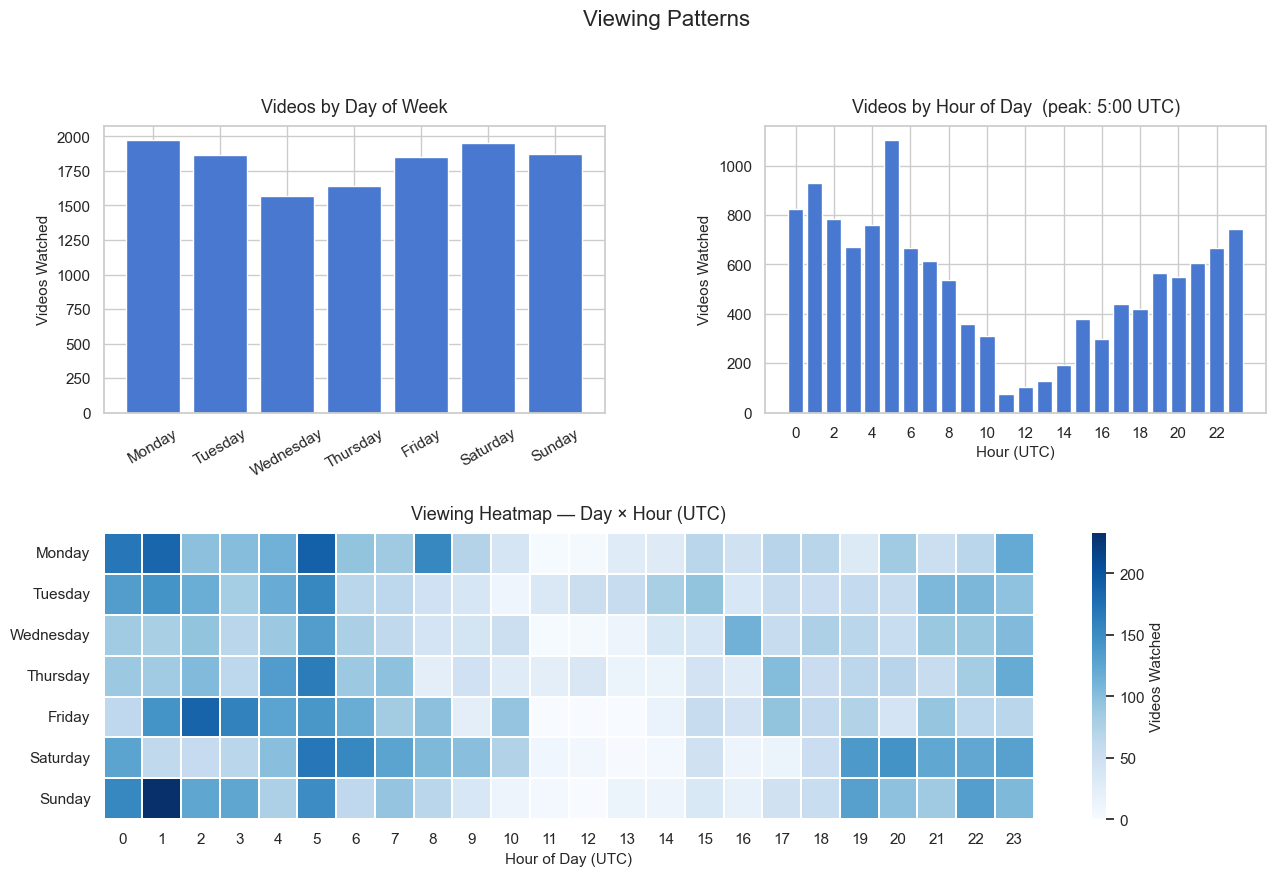

Peak hour: 5:00 UTC
Most active day: Monday
Weekend share: 30.1%  (3,826 of 12,727 videos)


In [8]:
DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

watch_only = df[df["source"] == "watch"].copy()

# Day-of-week 
views_dow = (
    watch_only.groupby("day_of_week").size()
    .reindex(DOW_ORDER)
    .reset_index(name="views")
)

# Hour-of-day 
views_hour = (
    watch_only.groupby("hour").size()
    .reset_index(name="views")
    .sort_values("hour")
)
peak_hour = views_hour.loc[views_hour["views"].idxmax(), "hour"]

# Day × Hour heatmap 
heat = (
    watch_only.groupby(["day_of_week", "hour"]).size()
    .reset_index(name="count")
    .pivot(index="day_of_week", columns="hour", values="count")
    .reindex(DOW_ORDER)
    .fillna(0)
)

# Plot 
fig = plt.figure(figsize=(15, 9))
gs  = GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# A: Day of week
ax_a = fig.add_subplot(gs[0, 0])
ax_a.bar(views_dow["day_of_week"], views_dow["views"])
ax_a.set_title("Videos by Day of Week")
ax_a.set_ylabel("Videos Watched")
ax_a.tick_params(axis="x", rotation=30)

# B: Hour of day
ax_b = fig.add_subplot(gs[0, 1])
ax_b.bar(views_hour["hour"], views_hour["views"], width=0.8)
ax_b.set_title(f"Videos by Hour of Day  (peak: {peak_hour}:00 UTC)")
ax_b.set_xlabel("Hour (UTC)")
ax_b.set_ylabel("Videos Watched")
ax_b.set_xticks(range(0, 24, 2))

# C: Heatmap 
ax_c = fig.add_subplot(gs[1, :])
sns.heatmap(
    heat, cmap="Blues", linewidths=0.3, linecolor="white",
    ax=ax_c, cbar_kws={"label": "Videos Watched"},
    annot=False
)
ax_c.set_title("Viewing Heatmap — Day × Hour (UTC)")
ax_c.set_xlabel("Hour of Day (UTC)")
ax_c.set_ylabel("")
ax_c.tick_params(axis="x", rotation=0)

fig.suptitle("Viewing Patterns", fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

print(f"Peak hour: {peak_hour}:00 UTC")
print(f"Most active day: {views_dow.loc[views_dow['views'].idxmax(), 'day_of_week']}")
wkd = watch_only["is_weekend"].sum()
print(f"Weekend share: {wkd/len(watch_only)*100:.1f}%  ({wkd:,} of {len(watch_only):,} videos)")


## 7. Content Preferences: Top Channels
Rank channels by watch count and measure how concentrated your viewing is.

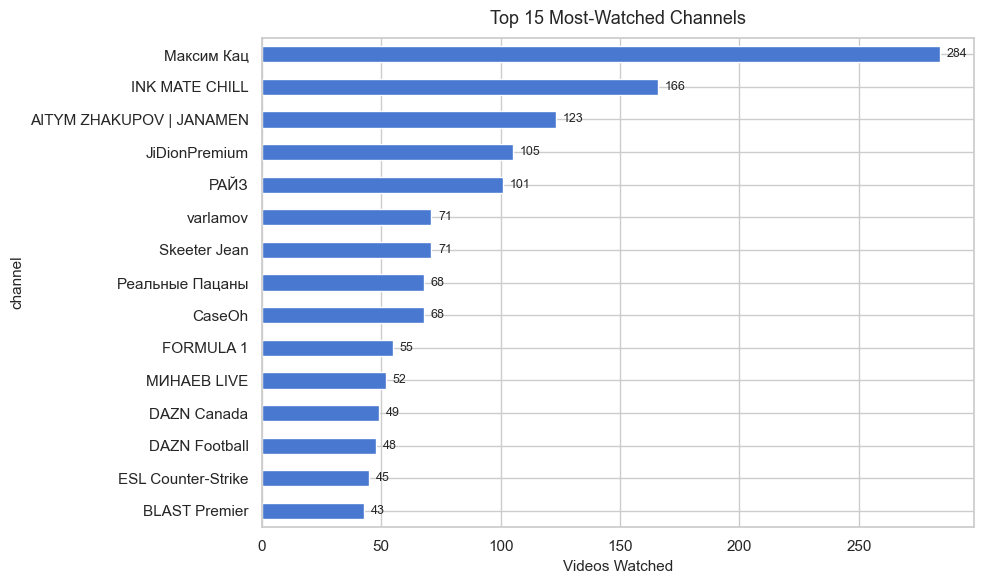

Top 15 channels account for 17.5% of all watches


In [9]:
# Build channel table directly from raw JSON (handles nested subtitles cleanly)
channel_rows = []
for item in watch_raw:
    subs = item.get("subtitles")
    if isinstance(subs, list) and subs:
        channel_rows.append({
            "time":    item.get("time"),
            "channel": subs[0].get("name"),
        })

ch_df = pd.DataFrame(channel_rows)
ch_df["time"]    = pd.to_datetime(ch_df["time"], errors="coerce", utc=True)
ch_df["channel"] = ch_df["channel"].str.strip()
ch_df = ch_df.dropna(subset=["time", "channel"])

top_channels = ch_df["channel"].value_counts().head(15)

# ── Bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
top_channels.sort_values().plot(kind="barh", ax=ax)
for i, val in enumerate(top_channels.sort_values().values):
    ax.text(val + max(top_channels) * 0.01, i, f"{val:,}", va="center", fontsize=9)
ax.set_title("Top 15 Most-Watched Channels")
ax.set_xlabel("Videos Watched")
fig.tight_layout()
plt.show()

top15_share = top_channels.sum() / len(ch_df)
print(f"Top 15 channels account for {top15_share:.1%} of all watches")


## 8. Search Behaviour
What do you actually search for? We analyse the raw query text, strip stopwords, and look at timing.


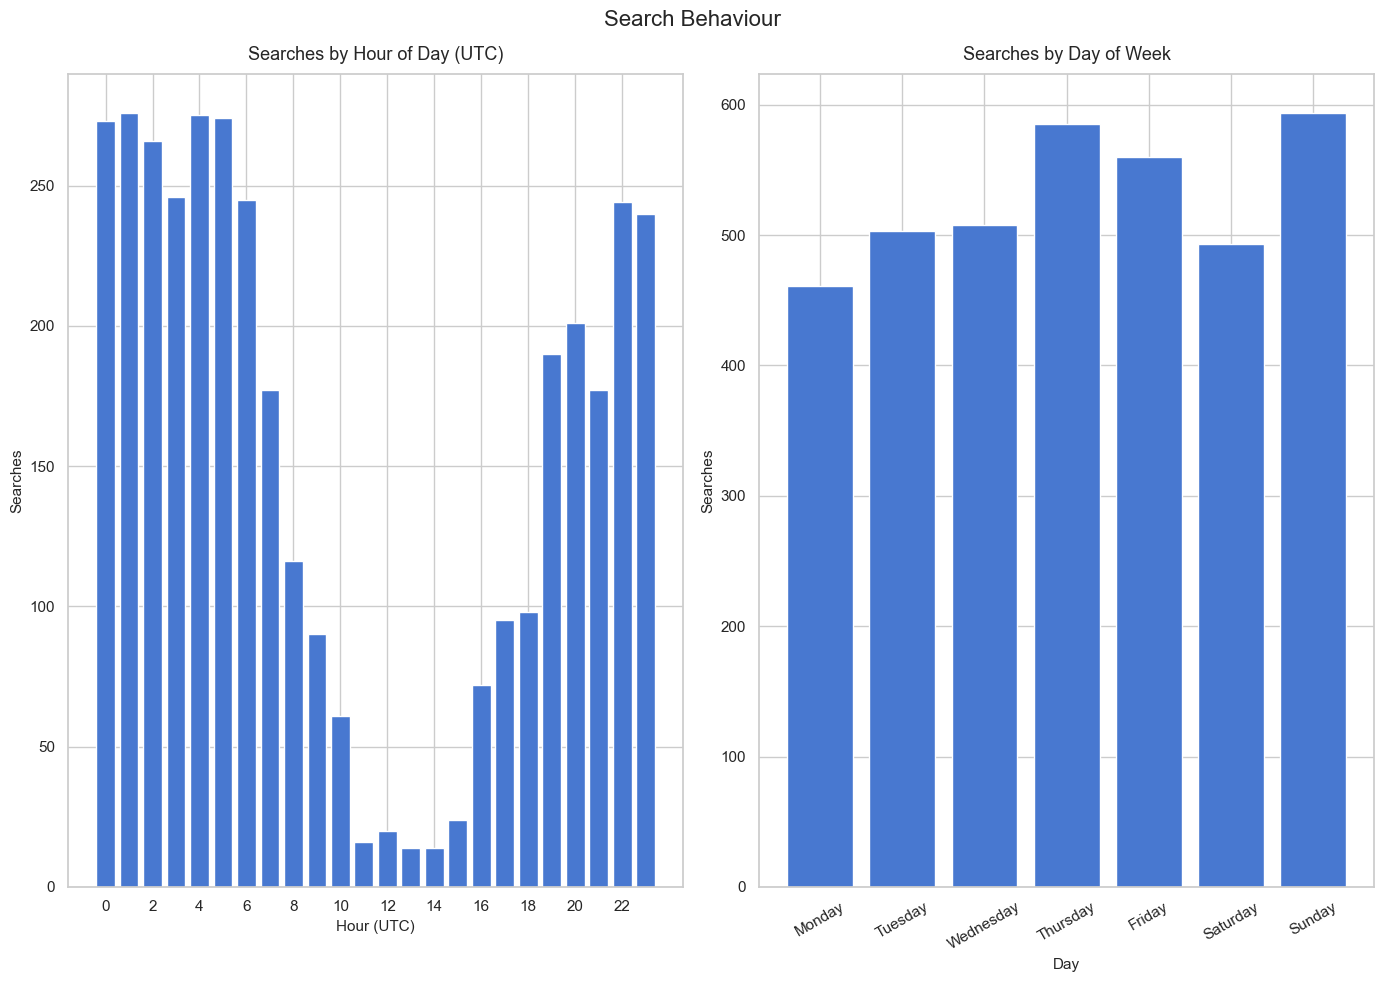

In [10]:
if search_df.empty:
    print("No search data available.")
else:
    # Timing 
    search_hour = search_df.groupby("hour").size()
    search_dow  = search_df.groupby("day_of_week").size().reindex(DOW_ORDER)

    # 2-panel plot 
    fig, axes = plt.subplots(1, 2, figsize=(14, 10))

    axes[0].bar(search_hour.index, search_hour.values, width=0.8)
    axes[0].set_title("Searches by Hour of Day (UTC)")
    axes[0].set_xlabel("Hour (UTC)")
    axes[0].set_ylabel("Searches")
    axes[0].set_xticks(range(0, 24, 2))

    axes[1].bar(search_dow.index, search_dow.values)
    axes[1].set_title("Searches by Day of Week")
    axes[1].set_xlabel("Day")
    axes[1].set_ylabel("Searches")
    axes[1].tick_params(axis="x", rotation=30)

    fig.suptitle("Search Behaviour", fontsize=16)
    fig.tight_layout()
    plt.show()

## 9. Year-over-Year & Binge Analysis
Three views:
1. Videos watched per year (bar)
2. Month × Year activity heatmap
3. Daily viewing distribution & top binge days

**Data Coverage Note:** 2026 counts are lower because the year is still in progress at export time. Interpret comparisons with prior full years cautiously.


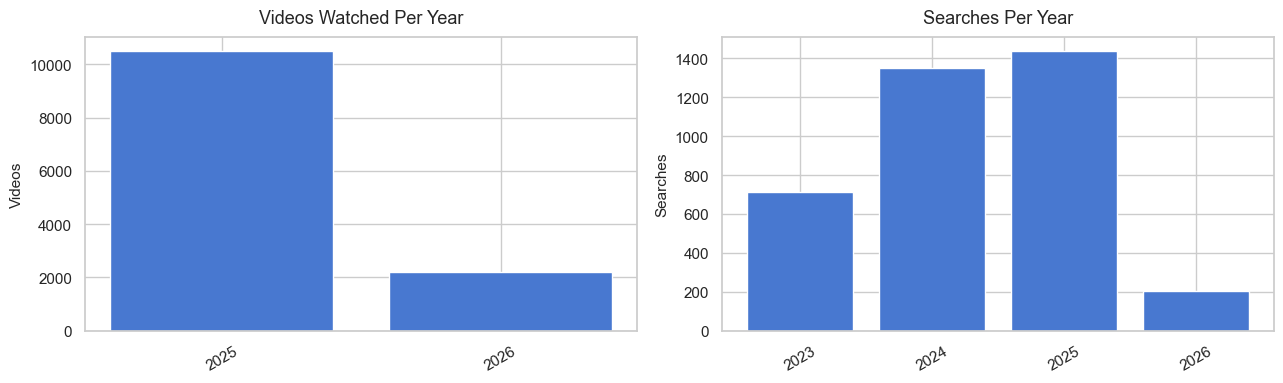

In [11]:
# ── Watches per year ─────────────────────────────────────────
watch_year_counts = watch_df.groupby("year").size().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar([str(y) for y in watch_year_counts.index], watch_year_counts.values)
axes[0].set_title("Videos Watched Per Year")
axes[0].set_ylabel("Videos")
axes[0].tick_params(axis="x", rotation=30)

if not search_df.empty:
    search_year_counts = search_df.groupby("year").size().sort_index()
    axes[1].bar([str(y) for y in search_year_counts.index], search_year_counts.values)
    axes[1].set_title("Searches Per Year")
    axes[1].set_ylabel("Searches")
    axes[1].tick_params(axis="x", rotation=30)
else:
    axes[1].set_visible(False)

fig.tight_layout()
plt.show()


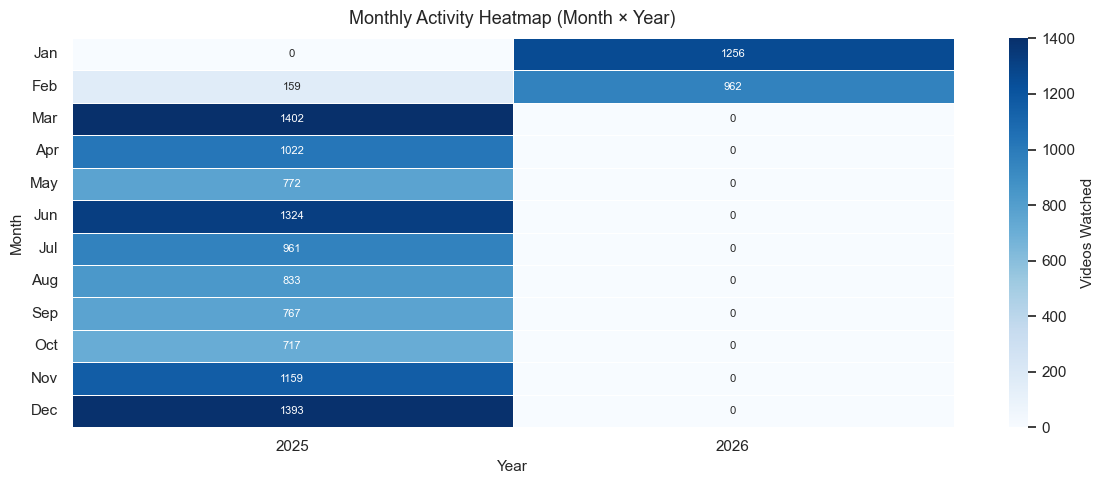

In [12]:
# ── Month × Year heatmap ─────────────────────────────────────
watch_pivot = (
    watch_df.pivot_table(index="month_num", columns="year", aggfunc="size", fill_value=0)
    .sort_index()
)

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    watch_pivot, cmap="Blues",
    linewidths=0.4, linecolor="white",
    ax=ax, cbar_kws={"label": "Videos Watched"},
    annot=True, fmt="d", annot_kws={"size": 8}
)
ax.set_title("Monthly Activity Heatmap (Month × Year)")
ax.set_xlabel("Year")
ax.set_ylabel("Month")
ax.set_yticklabels(MONTH_NAMES, rotation=0)
fig.tight_layout()
plt.show()


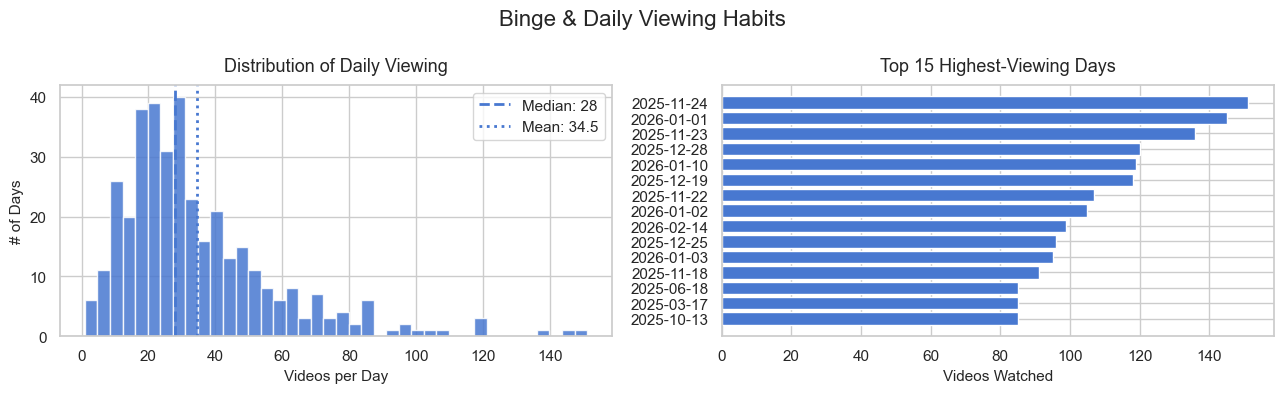

Average videos/day : 34.5
Median  videos/day : 28
Biggest binge day  : 151 videos on 2025-11-24


In [13]:
# ── Binge analysis ───────────────────────────────────────────
daily_counts = watch_df.groupby("date").size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(daily_counts.values, bins=40, edgecolor="white", alpha=0.85)
axes[0].axvline(daily_counts.median(), lw=2, ls="--",
                label=f"Median: {daily_counts.median():.0f}")
axes[0].axvline(daily_counts.mean(), lw=2, ls=":",
                label=f"Mean: {daily_counts.mean():.1f}")
axes[0].set_title("Distribution of Daily Viewing")
axes[0].set_xlabel("Videos per Day")
axes[0].set_ylabel("# of Days")
axes[0].legend()

top_days = daily_counts.sort_values(ascending=False).head(15)
axes[1].barh([str(d) for d in top_days.index[::-1]], top_days.values[::-1])
axes[1].set_title("Top 15 Highest-Viewing Days")
axes[1].set_xlabel("Videos Watched")

fig.suptitle("Binge & Daily Viewing Habits", fontsize=16)
fig.tight_layout()
plt.show()

print(f"Average videos/day : {daily_counts.mean():.1f}")
print(f"Median  videos/day : {daily_counts.median():.0f}")
print(f"Biggest binge day  : {daily_counts.max()} videos on {daily_counts.idxmax()}")


# 10. Exporting

## Export Privacy-Safe Outputs

This section exports aggregated datasets that contain no personal
watch history details. These files can safely be included in the
public GitHub repository.

In [14]:
from pathlib import Path

# Create output folder
OUTPUT_DIR = BASE_DIR / "data_processed"
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Watch counts by year ---
watch_counts_by_year = (
    watch_df.groupby("year")
    .size()
    .reset_index(name="watch_count")
)

watch_counts_by_year.to_csv(
    OUTPUT_DIR / "watch_counts_by_year.csv",
    index=False
)

# --- Search counts by year ---
if not search_df.empty:
    search_counts_by_year = (
        search_df.groupby("year")
        .size()
        .reset_index(name="search_count")
    )

    search_counts_by_year.to_csv(
        OUTPUT_DIR / "search_counts_by_year.csv",
        index=False
    )

# --- Top channels ---
top_channels_df = top_channels.reset_index()
top_channels_df.columns = ["channel", "watch_count"]

top_channels_df.to_csv(
    OUTPUT_DIR / "top_channels_top15.csv",
    index=False
)

print("Exports saved to:", OUTPUT_DIR)

Exports saved to: C:\Users\aisen\Documents\youtube-behavior-analysis\data_processed
